# A4 — the one-step network on the magnet-up field, where no labels exist

This notebook only **loads** what the scripts in this folder wrote; it recomputes nothing.
`README.md` maps each script to its outputs.

The question: the physics (label-free) loss needs only the field and the equation of
motion, so it should train on a polarity for which no reference trajectories exist.
Does it reach the same floor there as the magnet-down baseline reached, and does it sit
the same distance above the exact scheme's own ceiling?


In [1]:
import json, os
import numpy as np, pandas as pd
from IPython.display import Image, display

RES, FIG = 'results', 'figures'
load = lambda n: json.load(open(os.path.join(RES, n)))


## A4.1 — the field

Identity, the torch twin's parity gate on the up map (the physics loss takes its
gradients through that twin), and how the two polarities differ.


In [2]:
f = load('field_up_parity.json')
print('MagUp  ', f['up']['file'], f['up']['md5'])
print('MagDown', f['down']['file'], f['down']['md5'])
print()
for w in ('up','down'):
    p = f['parity_%s' % w]
    print('parity [%-4s] worst |numpy - torch| = %.3e T on %d points -> %s'
          % (w, p['max_abs_diff_T'], p['n_points'], 'PASS' if p['passes'] else 'FAIL'))
print()
print(json.dumps(f['mirror_test'], indent=1))


MagUp   /cvmfs/lhcb.cern.ch/lib/lhcb/DBASE/FieldMap/v8r1/cdf/field.v8r1.up.bin 9e49ddc4313b589f273540e7e0bb513b
MagDown /cvmfs/lhcb.cern.ch/lib/lhcb/DBASE/FieldMap/v8r1/cdf/field.v8r1.down.bin af284c6954d2273c637a5e766b82b58e

parity [up  ] worst |numpy - torch| = 1.332e-15 T on 200000 points -> PASS
parity [down] worst |numpy - torch| = 1.332e-15 T on 200000 points -> PASS

{
 "n_points": 200000,
 "max_abs_B_down_T": 4.467516157109472,
 "max_abs_Bup_plus_Bdown_T": [
  0.0,
  0.0,
  0.0
 ],
 "exact_sign_flip": true,
 "max_abs_diff_magnitude_T": 0.0,
 "median_abs_diff_magnitude_T": 0.0
}


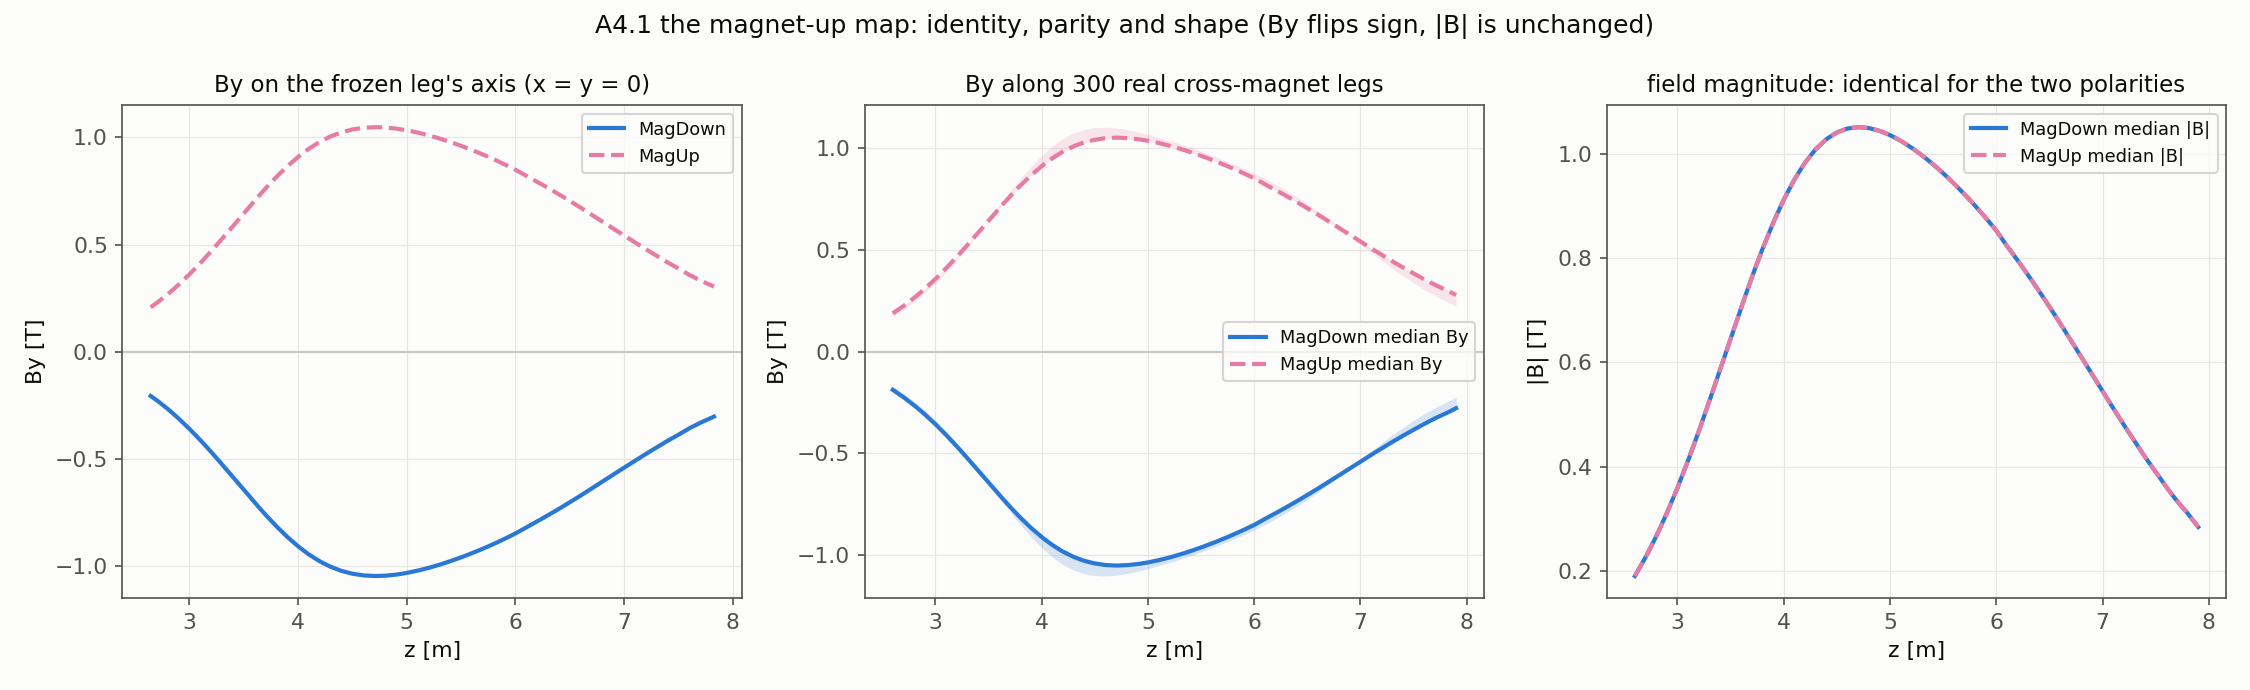

In [3]:
display(Image(os.path.join(FIG, 'field_up_vs_down.png')))


## A4.2 — the dataset

Same event rows for both polarities; only the field the reference trajectories are
integrated with changes. The fiducial cut is the interesting asymmetry.


In [4]:
m = load('dataset_meta.json')
print(pd.DataFrame({'up': m['up']['counts'], 'down': m['down']['counts'],
                    'dropped_up': m['up']['dropped_by_fiducial'],
                    'dropped_down': m['down']['dropped_by_fiducial']}))
print()
print(json.dumps(load('population_check.json'), indent=1))


         up  down  dropped_up  dropped_down
train  2000  1979           0            21
val    2082  2062           0            20
test   2033  2018           0            15

{
 "note": "the input population before the field is used at all",
 "train": {
  "n_selected_rows": 2000,
  "n_unique_tracks": 2000,
  "same_rows_for_both_polarities": true,
  "n_finite_after_transport_up": 2000,
  "n_finite_after_transport_down": 2000,
  "max_abs_state_difference_up_minus_down": [
   0.049661226647330636,
   0.011276054789163936,
   0.002509771347906309,
   0.0005699774762030207,
   0.0
  ],
  "median_abs_x_difference_mm": 0.00048132234834596943
 },
 "val": {
  "n_selected_rows": 2082,
  "n_unique_tracks": 2082,
  "same_rows_for_both_polarities": true,
  "n_finite_after_transport_up": 2082,
  "n_finite_after_transport_down": 2082,
  "max_abs_state_difference_up_minus_down": [
   0.04632036957249852,
   0.006139389084637514,
   0.002024770238244933,
   0.0006976684158161439,
   0.0
  ],
  "media

## A4.3 — the pre-submit gate on `--field`

One L-BFGS restart on the same states and the same seed, with the loss built on each
polarity in turn. If the flag did not reach the loss the two numbers would be equal.


In [5]:
print(json.dumps(load('loss_field_probe.json'), indent=1))


{
 "what": "one L-BFGS restart, same seed and same up-field dataset, with the physics loss built on each polarity in turn",
 "loss_after_one_restart": {
  "up": 0.00262150329156261,
  "down": 0.00803173013953939
 },
 "field_recorded_in_json": {
  "up": "up",
  "down": "down"
 },
 "test_endpoint_med_um_vs_up_references": {
  "up": 8407.884662936567,
  "down": 1039322.1163791097
 },
 "losses_differ": true,
 "ratio_down_over_up": 3.0637879286246803
}


## A4.3 — the 13 runs


In [6]:
s = pd.read_csv(os.path.join(RES, 'summary.csv'))
display(s[['tag','mode','seed','field','converged','restarts','final_loss',
           'train_med_um','val_med_um','test_med_um','test_p95_um']])
print('converged: %d of %d' % (s.converged.sum(), len(s)))
for mode in ('physics','data'):
    v = s.loc[s['mode']==mode, 'test_med_um']
    if len(v):
        print('%-8s test endpoint median: %.0f um  [%.0f - %.0f] over %d seeds'
              % (mode, v.median(), v.min(), v.max(), len(v)))


,tag,mode,seed,field,converged,restarts,final_loss,train_med_um,val_med_um,test_med_um,test_p95_um
0,up_data_s0,data,0,up,True,114,0.000005,214.580435,219.601613,204.163408,2859.132254
1,up_data_s1,data,1,up,True,94,0.000006,238.699033,231.551998,230.100724,2782.817545
2,up_data_s2,data,2,up,True,134,0.000005,197.423179,199.764244,186.741623,2785.896071
3,up_physics_s0,physics,0,up,True,125,0.000011,218.397224,223.218547,219.392190,3871.563760
4,up_physics_s1,physics,1,up,True,115,0.000015,246.566455,258.207665,241.636290,4588.509743
5,up_physics_s2,physics,2,up,True,116,0.000014,250.636834,261.833541,229.526125,4962.203143
6,up_physics_s3,physics,3,up,True,131,0.000011,179.640525,174.875734,170.553356,4183.827534
7,up_physics_s4,physics,4,up,True,152,0.000013,311.882845,322.275334,296.494440,4419.658061
8,up_physics_s5,physics,5,up,True,123,0.000013,310.018290,317.038137,279.066808,4510.699549
9,up_physics_s6,physics,6,up,True,114,0.000017,244.741144,268.316774,230.509334,4719.061804


converged: 13 of 13
physics  test endpoint median: 229 um  [171 - 296] over 10 seeds
data     test endpoint median: 204 um  [187 - 230] over 3 seeds


## A4.4 — the ceiling, and the comparison table

The exact Gauss-Legendre scheme (q = 8, no network) solved on the same 32
momentum-stratified leg-B states with each field: the floor under anything a network
trained on those equations can reach.


In [7]:
print(json.dumps(load('ceiling_summary.json'), indent=1))
c = pd.read_csv(os.path.join(RES, 'ceiling_up.csv'))
display(c.groupby('field')[['err_endpoint_um','n_evals','converged']].describe().T)


{
 "q": 8,
 "leg": "B",
 "n_states": 32,
 "seed": 20260718,
 "per_field": {
  "up": {
   "n": 32,
   "n_converged": 32,
   "converged_frac": 1.0,
   "median_err_um": 33.16862466988724,
   "p95_err_um": 865.4849003306524,
   "worst_err_um": 37836.67055042974,
   "median_n_evals": 44
  },
  "down": {
   "n": 32,
   "n_converged": 31,
   "converged_frac": 0.96875,
   "median_err_um": 32.040678874295736,
   "p95_err_um": 83508.40655311823,
   "worst_err_um": 258429.16988995738,
   "median_n_evals": 44
  }
 },
 "on_the_test_states": {
  "up": {
   "n": 2033,
   "converged_frac": 1.0,
   "endpoint_med_um": 22.103423479109097,
   "endpoint_p95_um": 1544.6273956574257,
   "endpoint_mean_um": 657.4858871786739,
   "stage_med_um": 27.214570694241047
  },
  "down": {
   "n": 2018,
   "converged_frac": 1.0,
   "endpoint_med_um": 22.544094616847588,
   "endpoint_p95_um": 1609.9007786735729,
   "endpoint_mean_um": 613.4675594696984,
   "stage_med_um": 26.39244205823843
  }
 },
 "note": "per_field = 

field                          down            up
err_endpoint_um count  3.200000e+01     32.000000
                mean   9.713938e+04   1381.183542
                std    4.512607e+05   7071.229579
                min    1.087972e+00      0.988723
                25%    1.118236e+01     12.391186
                50%    3.537058e+01     33.277557
                75%    4.880362e+02    113.047991
                max    2.546251e+06  40106.045614
n_evals         count  3.200000e+01     32.000000
                mean   5.487500e+01     45.718750
                std    5.109873e+01      6.081354
                min    4.200000e+01     42.000000
                25%    4.300000e+01     43.000000
                50%    4.450000e+01     44.500000
                75%    4.700000e+01     46.000000
                max    3.330000e+02     77.000000
converged       count  3.200000e+01     32.000000
                mean   9.687500e-01      1.000000
                std    1.767767e-01      0.000000
                min    0.000000e+00      1.000000
                25%    1.000000e+00      1.000000
                50%    1.000000e+00      1.000000
                75%    1.000000e+00      1.000000
                max    1.000000e+00      1.000000

In [8]:
display(pd.read_csv(os.path.join(RES, 'up_vs_down.csv')))


,quantity,field,median_um,min_um,max_um,n_seeds,note
0,"network, physics loss (label-free)",up,229.40,170.60,296.50,10,this experiment; converged 10/10; restarts 114...
1,"network, physics loss (label-free)",down,220.80,163.00,243.80,10,A1 Network_size_and_seed_study 50x4; converged...
2,"network, physics loss (label-free), converged ...",down,232.70,213.20,243.80,5,"A1 50x4, the runs that confirmed"
3,"network, physics loss (label-free)",down,182.70,177.40,235.40,3,"One_step_network_v2 baseline, 3 seeds, 4 BLAS ..."
4,"network, data loss (supervised twin)",up,204.20,186.70,230.10,3,this experiment; converged 3/3; restarts 94-134
5,"network, data loss (supervised twin)",down,191.80,162.40,207.50,3,"One_step_network_v2 baseline, 3 seeds, 4 BLAS ..."
6,"exact-scheme ceiling, on the test states",up,22.10,22.10,1544.60,2033,"q=8, all test states; max_um column is the p95..."
7,"exact-scheme ceiling, on the test states",down,22.50,22.50,1609.90,2018,"q=8, all test states; max_um column is the p95..."
8,"exact-scheme ceiling, 32 stratified legs",up,33.20,33.20,37836.70,32,the Simple_first_pass population; max_um is th...
9,"exact-scheme ceiling, 32 stratified legs",down,32.00,32.00,258429.20,32,the Simple_first_pass population; max_um is th...


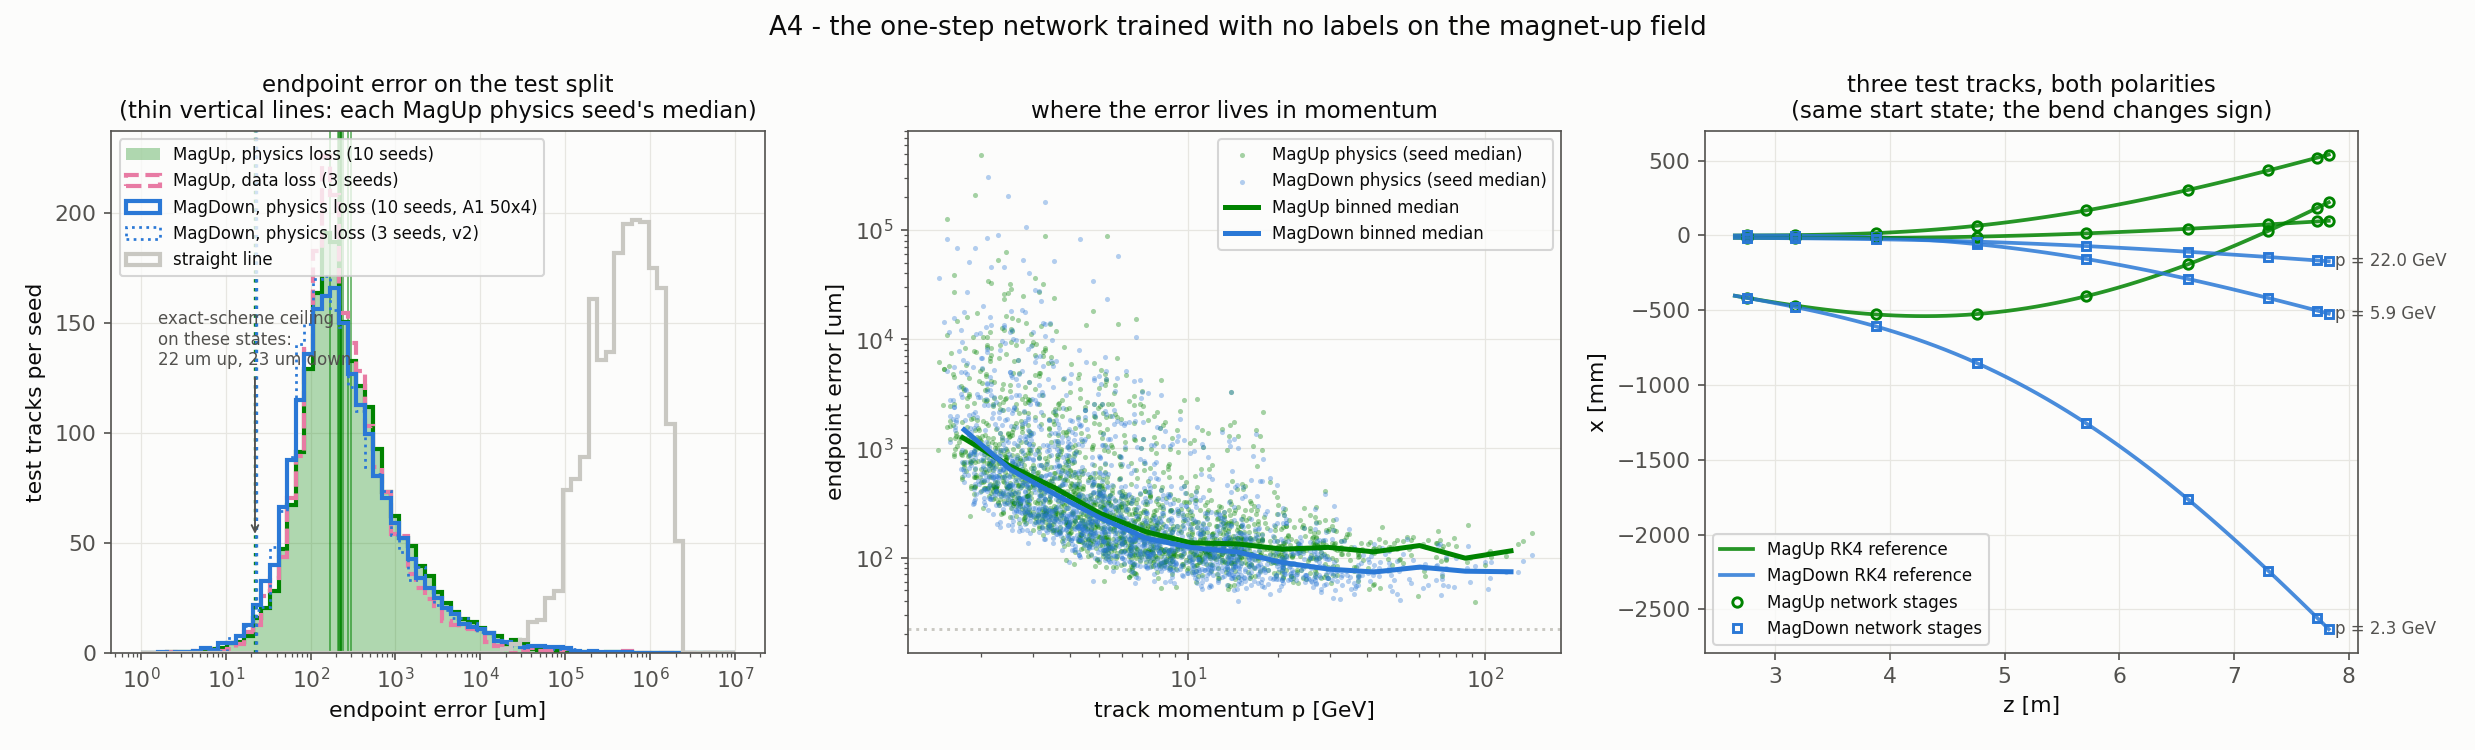

In [9]:
display(Image(os.path.join(FIG, 'magnet_up_results.png')))


## A4.5 — verdict

See `README.md`.
